# Unit 1: OpenBCI Cyton 设备基础与生物电信号理论

## 学习目标

- 理解 OpenBCI Cyton 的硬件架构及各组件功能
- 掌握 ADS1299 模拟前端的工作原理与关键参数
- 了解 EEG/EMG/ECG 信号的生物学起源与特征
- 熟悉国际 10-20 电极放置系统
- 能够计算关键性能指标（分辨率、动态范围、输入阻抗等）

---

## 1.1 OpenBCI Cyton 硬件架构

OpenBCI Cyton 是一款 **8 通道、24 位精度** 的开源生物电信号采集设备。其核心硬件模块包括：

| 模块 | 型号 | 功能 |
|------|------|------|
| **模拟前端 (AFE)** | TI ADS1299 | 8 通道同步采样，24-bit ΔΣ ADC，可编程增益放大器 |
| **微控制器 (MCU)** | Microchip PIC32MX250F128B | 32-bit MIPS M4K，50 MHz，128KB Flash，32KB RAM |
| **加速度计** | ST LIS3DH | 3 轴 ±16g，用于运动伪迹检测 |
| **无线模块** | RFDuino (nRF51822) | BLE 4.0，Nordic Gazelle 协议栈，最高 250 kbps |
| **存储** | Micro SD 卡槽 | FAT32，最大支持 32GB，支持离线记录 |
| **电源** | 3–6V DC 电池供电 | 电池隔离确保低噪声，3.3V / ±2.5V 片上稳压 |

### 关键设计理念

- **电池供电**：与市电完全隔离，避免 50/60 Hz 接地回路噪声
- **差分输入**：每个通道测量两个电极之间的电压差
- **右腿驱动 (RLD)**：主动抵消共模干扰
- **菊花链 (Daisy Chain)**：通过 Daisy 模块可扩展到 16 通道

## 1.2 ADS1299 模拟前端详解

ADS1299 是 TI 专为生物电位测量设计的低噪声、多通道 ΔΣ ADC。

### 核心参数

| 参数 | 值 | 说明 |
|------|-----|------|
| 分辨率 | 24 bits | 理论动态范围 ~144 dB |
| 采样率 | 250 SPS (默认) | 可配置 250/500/1000/2000/4000/8000/16000 SPS |
| 输入参考噪声 | ≤1.0 μVpp (70 Hz BW) | 极低噪声适合 EEG |
| CMRR | ≥110 dB | 优秀的共模抑制能力 |
| 输入阻抗 | ≥1000 MΩ | 适应高阻抗电极 |
| 可编程增益 | 1, 2, 4, 6, 8, 12, 24 | 适应不同信号幅值 |
| 参考电压 | 内部 4.5V (VREF) | ADC 满量程基准 |

### ADC 量化计算

24 位 ADC 的量化步长（LSB）：

$$\text{LSB} = \frac{V_{REF}}{2^{23} \cdot G} = \frac{4.5}{8388608 \cdot G} \text{ V}$$

转换为 μV 的标定因子 (G=24 时)：

$$\text{ScaleFactor} = \frac{4.5}{2^{23} \cdot 24} \times 10^6 \approx 0.02235 \text{ μV/count}$$

In [1]:
# ============================================================
# 代码 1.1: ADS1299 ADC 量化参数计算
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ADS1299 参数
VREF = 4.5          # 参考电压 (V) 由 ADS1299 芯片内部的硬件电路设计决定
BITS = 24           # ADC 分辨率
GAINS = [1, 2, 4, 6, 8, 12, 24]  # 可编程增益选项

print("=" * 60)
print("ADS1299 ADC 量化参数")
print("=" * 60)
print(f"参考电压 VREF:                 {VREF} V")
print(f"ADC 分辨率:                     {BITS} bits")
print(f"最大编码值 (2^23 - 1):          {2**23 - 1:,}")
print()
# 权衡“看得清细节的能力”和“能容纳的最大信号范围”
for gain in GAINS:
    # LSB 电压 = VREF / (2^23 * Gain)
    lsb_voltage = VREF / ((2**23) * gain)  # V
    lsb_uv = lsb_voltage * 1e6              # muV
    # 输入范围 (差分, 正负对称)
    input_range_mv = (VREF / gain) * 1000    # mVpp
    
    print(f"Gain = {gain:2d}:  "
          f"LSB = {lsb_uv:.4f} uV,  "                   # 输入电压分辨率
          f"Input Range = +/-{input_range_mv/2:.1f} mV") # 输入电压范围

ADS1299 ADC 量化参数
参考电压 VREF:                 4.5 V
ADC 分辨率:                     24 bits
最大编码值 (2^23 - 1):          8,388,607

Gain =  1:  LSB = 0.5364 uV,  Input Range = +/-2250.0 mV
Gain =  2:  LSB = 0.2682 uV,  Input Range = +/-1125.0 mV
Gain =  4:  LSB = 0.1341 uV,  Input Range = +/-562.5 mV
Gain =  6:  LSB = 0.0894 uV,  Input Range = +/-375.0 mV
Gain =  8:  LSB = 0.0671 uV,  Input Range = +/-281.2 mV
Gain = 12:  LSB = 0.0447 uV,  Input Range = +/-187.5 mV
Gain = 24:  LSB = 0.0224 uV,  Input Range = +/-93.8 mV


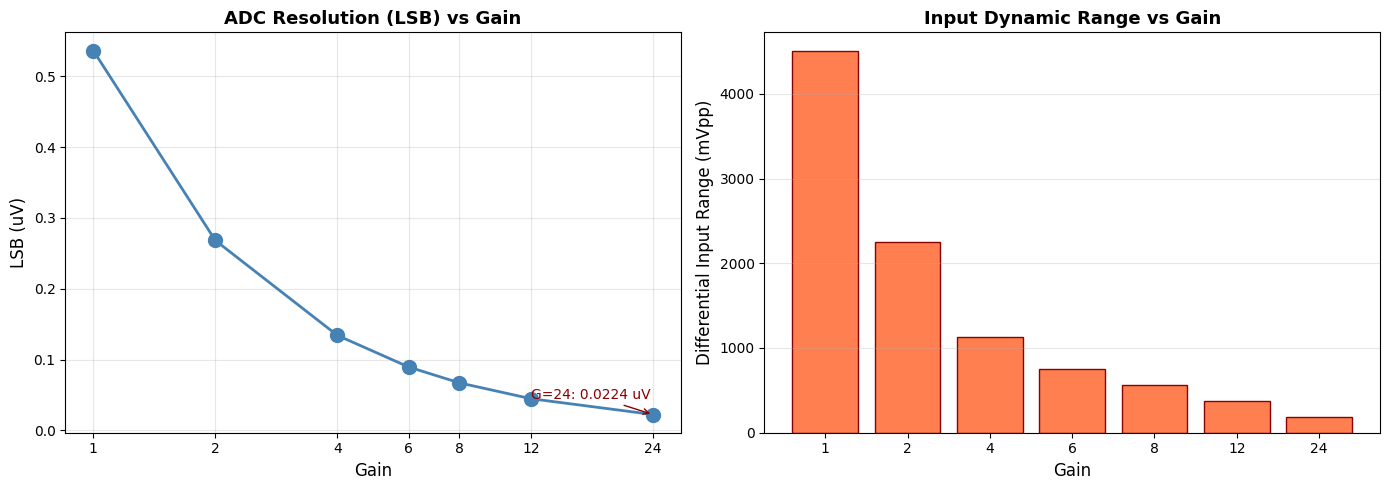


关键观察:
- 增益越高，LSB 越小（分辨率越高），但输入范围也越小
- EEG 信号典型幅值 10-100 uV，G=24 时 LSB=0.022 uV，完全足够
- EMG 信号可达 1-10 mV，需要考虑较低增益避免饱和


In [2]:
# ============================================================
# 代码 1.2: 增益与噪声性能可视化
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：LSB vs Gain
lsb_values = [VREF / ((2**23) * g) * 1e6 for g in GAINS]
ax1.plot(GAINS, lsb_values, "o-", color="steelblue", markersize=10,
         linewidth=2)
ax1.set_xlabel("Gain", fontsize=12)
ax1.set_ylabel("LSB (uV)", fontsize=12)
ax1.set_title("ADC Resolution (LSB) vs Gain", fontsize=13, fontweight="bold")
ax1.set_xscale("log", base=2)
ax1.set_xticks(GAINS)
ax1.set_xticklabels([str(g) for g in GAINS])
ax1.grid(True, alpha=0.3)

# 标注关键点
ax1.annotate(
    f"G=24: {lsb_values[-1]:.4f} uV",
    xy=(24, lsb_values[-1]),         # 标注箭头指向的位置（G=24对应的LSB值）
    xytext=(12, lsb_values[-1] * 2), # 标注文本的位置（箭头起点）
    arrowprops=dict(arrowstyle="->", color="darkred"), 
    fontsize=10,
    color="darkred"
)

# 右图：输入范围 vs Gain
input_ranges_mv = [(VREF / g) * 1000 for g in GAINS]
ax2.bar(range(len(GAINS)), input_ranges_mv, color="coral", edgecolor="darkred")
ax2.set_xlabel("Gain", fontsize=12)
ax2.set_ylabel("Differential Input Range (mVpp)", fontsize=12)
ax2.set_title("Input Dynamic Range vs Gain", fontsize=13, fontweight="bold")
ax2.set_xticks(range(len(GAINS)))
ax2.set_xticklabels([str(g) for g in GAINS])
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n关键观察:")
print("- 增益越高，LSB 越小（分辨率越高），但输入范围也越小")
print("- EEG 信号典型幅值 10-100 uV，G=24 时 LSB=0.022 uV，完全足够")
print("- EMG 信号可达 1-10 mV，需要考虑较低增益避免饱和")

## 1.3 生物电信号的生物学基础

### EEG（脑电图）

EEG 记录大脑皮层锥体神经元突触后电位的总和。关键特征：

| 频段 | 频率范围 | 典型幅值 | 关联状态 |
|------|----------|----------|----------|
| δ (Delta) | 0.5–4 Hz | 20–200 μV | 深度睡眠、婴儿 |
| θ (Theta) | 4–8 Hz | 10–50 μV | 困倦、冥想 |
| α (Alpha) | 8–13 Hz | 20–60 μV | 闭眼放松 |
| β (Beta) | 13–30 Hz | 5–20 μV | 专注、警觉 |
| γ (Gamma) | 30–100 Hz | 1–10 μV | 高级认知加工 |

### EMG（肌电图）

记录骨骼肌运动单位的动作电位：
- 频率范围：20–500 Hz（主要能量在 50–150 Hz）
- 幅值范围：0.1–10 mV（比 EEG 大约 100 倍！）
- 关键应用：手势识别、假肢控制、运动分析

### ECG（心电图）

记录心肌细胞的去极化和复极化过程：
- 频率范围：0.05–100 Hz（诊断通常用 0.5–40 Hz）
- 幅值：1–5 mV
- PQRST 复合波形态分析

In [12]:
# ============================================================
# 代码 1.3: 模拟生成不同生物电信号
# ============================================================
import sys
# 添加父目录到系统路径，以便导入上级utils目录的模块
# 当前脚本的父目录添加到 Python 的模块搜索路径最前端 
# 以便能够导入上级目录中的自定义模块。
sys.path.insert(0, "..")
from utils.helpers import generate_synthetic_eeg, plot_eeg_channels, plot_psd

# 生成模拟 EEG 信号（闭眼 alpha 主导）
print("生成模拟 EEG 信号...")
eeg_data, times = generate_synthetic_eeg(
    duration=5.0, sfreq=250.0, n_channels=4,
    noise_level=3.0, alpha_power=40.0, seed=123
)
print("模拟 EEG 信号生成完成")


生成模拟 EEG 信号...
模拟 EEG 信号生成完成


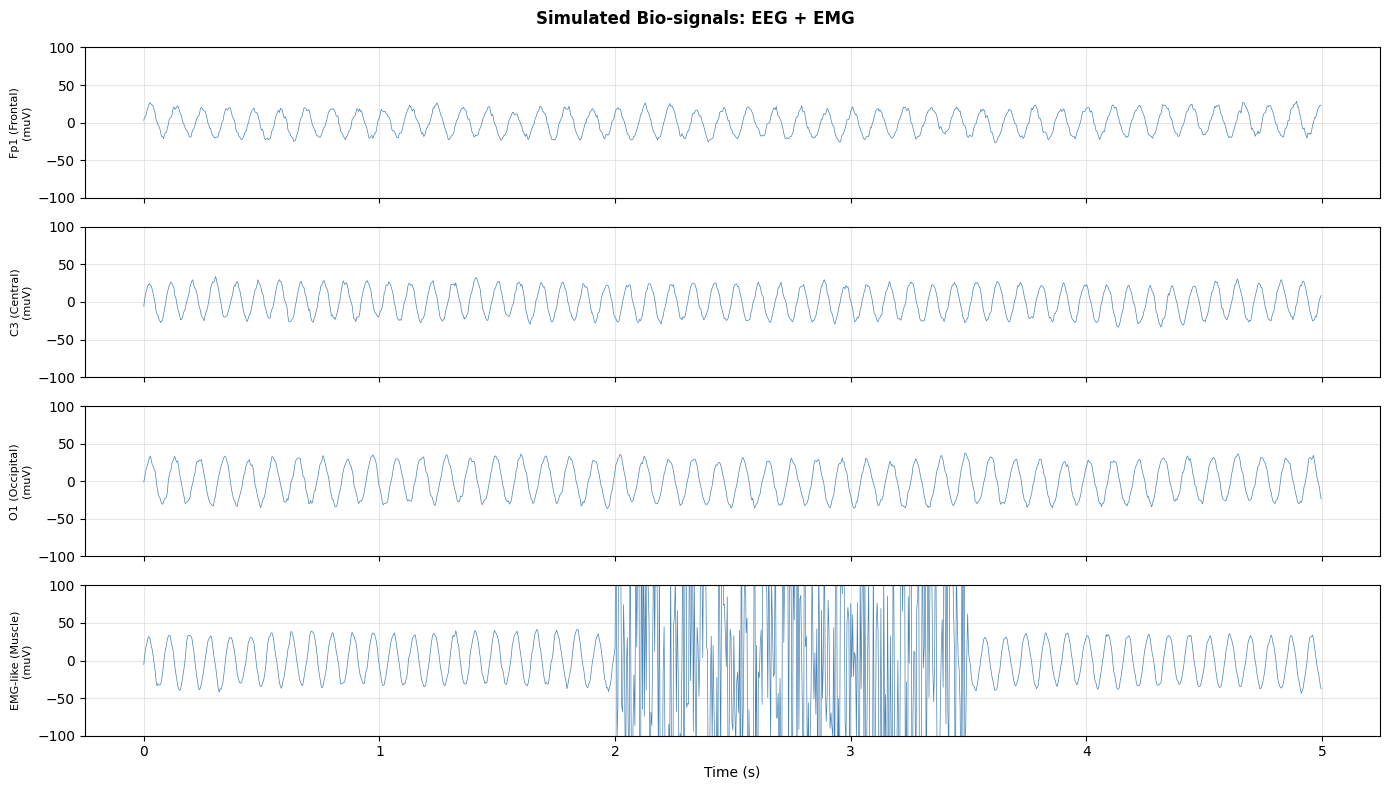

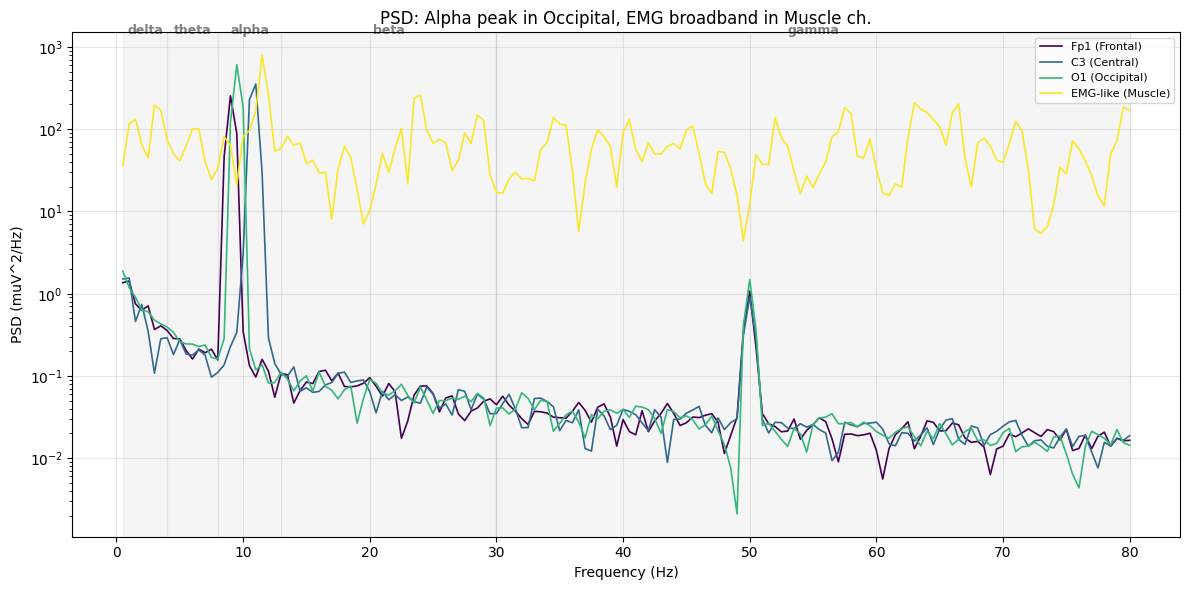


观察要点:
- 枕叶通道 (O1) 在 8-13 Hz 有明显 alpha 峰值
- 肌肉通道在高频段 (>30 Hz) 有宽带能量
- EEG 信号幅值通常在 +/-50 uV 范围内


In [13]:
# 添加模拟 EMG 特征到通道 4（高频成分）
rng = np.random.default_rng(456)
emg_burst = rng.normal(0, 50, len(times))
# 只在中间时间段添加 EMG 活动
emg_mask = (times > 2.0) & (times < 3.5)
# 将EMG爆发信号叠加到第4通道（索引3）的选定时间段上，乘以系数3增强信号强度
eeg_data[3, emg_mask] += emg_burst[emg_mask] * 3

# 绘制时域波形
channel_names = ["Fp1 (Frontal)", "C3 (Central)", "O1 (Occipital)", "EMG-like (Muscle)"]
fig1 = plot_eeg_channels(eeg_data, times, channel_names=channel_names,
                         title="Simulated Bio-signals: EEG + EMG")
plt.show()

# 绘制功率谱
fig2 = plot_psd(eeg_data, sfreq=250.0, channel_names=channel_names,
                title="PSD: Alpha peak in Occipital, EMG broadband in Muscle ch.")
plt.show()

print("\n观察要点:")
print("- 枕叶通道 (O1) 在 8-13 Hz 有明显 alpha 峰值")
print("- 肌肉通道在高频段 (>30 Hz) 有宽带能量")
print("- EEG 信号幅值通常在 +/-50 uV 范围内")

## 1.4 国际 10-20 电极放置系统

10-20 系统是 EEG 电极放置的国际标准。命名规则：

- **字母前缀**：F (Frontal/额叶)、C (Central/中央)、P (Parietal/顶叶)、O (Occipital/枕叶)、T (Temporal/颞叶)、Fp (Frontopolar/额极)
- **数字后缀**：奇数=左侧，偶数=右侧，z=中线 (zero)
- **"10-20" 含义**：相邻电极间距为鼻根-枕外隆突或耳前点间距的 10% 或 20%

### OpenBCI Cyton 8 通道典型配置

| 物理通道 | 10-20 位置 | 脑区 | 典型应用 |
|----------|-----------|------|----------|
| CH1 | Fp1 | 前额叶左 | 前额 EEG |
| CH2 | Fp2 | 前额叶右 | 前额 EEG |
| CH3 | C3 | 中央左 | 运动想象 (MI) |
| CH4 | C4 | 中央右 | 运动想象 (MI) |
| CH5 | P7 | 顶叶左 | 视觉诱发电位 |
| CH6 | P8 | 顶叶右 | 视觉诱发电位 |
| CH7 | O1 | 枕叶左 | α 波/VEP |
| CH8 | O2 | 枕叶右 | α 波/VEP |

### 参考电极选择

- **耳垂参考 (A1/A2)**：传统选择，信号稳定
- **乳突参考**：骨导电少，常用于 ERP 研究
- **Cz 参考**：位于头顶中央，方便但可能引入中央区伪迹
- **平均参考**：软件计算所有通道平均值，消除共享噪声

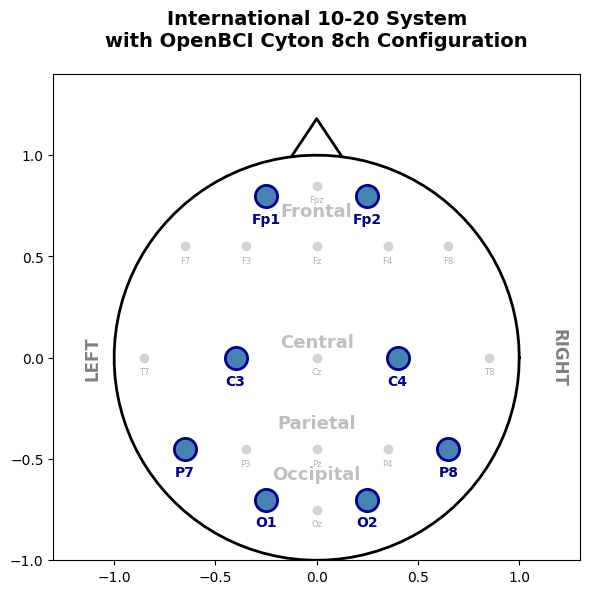


Cyton 8 通道 10-20 映射:
  CH1: Fp1   (x=-0.25, y=+0.80)
  CH2: Fp2   (x=+0.25, y=+0.80)
  CH3: C3    (x=-0.40, y=+0.00)
  CH4: C4    (x=+0.40, y=+0.00)
  CH5: P7    (x=-0.65, y=-0.45)
  CH6: P8    (x=+0.65, y=-0.45)
  CH7: O1    (x=-0.25, y=-0.70)
  CH8: O2    (x=+0.25, y=-0.70)


In [16]:
# ============================================================
# 代码 1.4: 10-20 系统可视化与通道映射
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# 简化的 10-20 系统坐标（仅用于示意）
# 使用头部俯视图（鼻子朝上）
ten_twenty_positions = {
    # 前额区
    "Fp1": (-0.25, 0.80), "Fpz": (0.0, 0.85), "Fp2": (0.25, 0.80),
    # 额区
    "F7": (-0.65, 0.55), "F3": (-0.35, 0.55), "Fz": (0.0, 0.55),
    "F4": (0.35, 0.55), "F8": (0.65, 0.55),
    # 中央区
    "T7": (-0.85, 0.0), "C3": (-0.40, 0.0), "Cz": (0.0, 0.0),
    "C4": (0.40, 0.0), "T8": (0.85, 0.0),
    # 顶区
    "P7": (-0.65, -0.45), "P3": (-0.35, -0.45), "Pz": (0.0, -0.45),
    "P4": (0.35, -0.45), "P8": (0.65, -0.45),
    # 枕区
    "O1": (-0.25, -0.70), "Oz": (0.0, -0.75), "O2": (0.25, -0.70),
}

# Cyton 8 通道映射（典型 BCI 配置）
cyton_channels = ["Fp1", "Fp2", "C3", "C4", "P7", "P8", "O1", "O2"]

fig, ax = plt.subplots(figsize=(6, 6))

# 绘制头部轮廓
# 生成 0 到 2π 之间的 100 个等间距角度值，用于绘制圆形
theta = np.linspace(0, 2*np.pi, 100)
# 使用极坐标转直角坐标公式绘制单位圆（头部轮廓）
# x = cos(θ), y = sin(θ)，"k-" 表示黑色实线，线宽为 2
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=2)
# 鼻子
ax.plot([-0.12, 0, 0.12], [1.0, 1.18, 1.0], "k-", linewidth=2)

# 绘制所有 10-20 位置（灰色小点）
for name, (x, y) in ten_twenty_positions.items():
    if name in cyton_channels:
        # Cyton 通道：高亮显示
        ax.plot(x, y, "o", markersize=16, color="steelblue",
                markeredgecolor="darkblue", markeredgewidth=2, zorder=5)
        ax.text(x, y - 0.08, name, ha="center", va="top", fontsize=10,
                fontweight="bold", color="darkblue")
    else:
        # 其他位置：灰色参考
        ax.plot(x, y, "o", markersize=6, color="lightgray", zorder=4)
        ax.text(x, y - 0.05, name, ha="center", va="top", fontsize=6,
                color="gray", alpha=0.6)

# 标注脑区
ax.text(0, 0.70, "Frontal", ha="center", fontsize=13, fontweight="bold",
        color="gray", alpha=0.5)
ax.text(0, 0.05, "Central", ha="center", fontsize=13, fontweight="bold",
        color="gray", alpha=0.5)
ax.text(0, -0.35, "Parietal", ha="center", fontsize=13, fontweight="bold",
        color="gray", alpha=0.5)
ax.text(0, -0.60, "Occipital", ha="center", fontsize=13, fontweight="bold",
        color="gray", alpha=0.5)

# 左右标注
ax.text(
    -1.15,  # x: 文本的x坐标位置，负值表示在头部左侧
    0,      # y: 文本的y坐标位置，0表示垂直居中
    "LEFT", # s: 要显示的文本字符串
    va="center",     # verticalalignment: 垂直对齐方式，"center"表示垂直居中
    fontsize=12,     # 字体大小，单位为点
    fontweight="bold",  # 字体粗细，"bold"表示粗体
    color="gray",    # 文本颜色
    rotation=90      # 文本旋转角度，90度表示顺时针旋转90度（垂直显示）
)
ax.text(1.15, 0, "RIGHT", va="center", fontsize=12, fontweight="bold",
        color="gray", rotation=-90)

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.0, 1.4)
ax.set_aspect("equal")
# ax.axis("off")
ax.set_title("International 10-20 System\nwith OpenBCI Cyton 8ch Configuration",
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

print("\nCyton 8 通道 10-20 映射:")
for i, ch in enumerate(cyton_channels, 1):
    pos = ten_twenty_positions[ch]
    print(f"  CH{i}: {ch:4s}  (x={pos[0]:+.2f}, y={pos[1]:+.2f})")

## 1.5 关键性能指标计算

### 理论动态范围 (Dynamic Range)
它回答了这样一个问题：在最大的信号不爆表（削波）的前提下，最小的信号能被放大多少倍还能被听见？

$$\text{DR}_{\text{dB}} = 20 \cdot \log_{10}(2^{N}) \approx 6.02 \cdot N$$

其中 $N$ 为有效位数 (ENOB)。对于 ADS1299，ENOB 通常为 19-20 位。

### 共模抑制比 (CMRR)
这个指标衡量的是芯片“抗干扰能力”有多强

$$\text{CMRR}_{\text{dB}} = 20 \cdot \log_{10}\left(\frac{A_d}{A_c}\right)$$

其中 $A_d$ 为差模增益，$A_c$ 为共模增益。ADS1299 的 CMRR ≥ 110 dB。

### 输入参考噪声 (IRN)
芯片的“本底噪声”

ADS1299 在 70 Hz 带宽下的 IRN ≤ 1.0 μVpp，远小于典型 EEG 信号幅值 (10-100 μV)。

In [26]:
# ============================================================
# 代码 1.5: 性能指标计算与 Nyquist 定理
# ============================================================
import numpy as np

# 理论动态范围
N_bits = 24
DR_ideal_db = 20 * np.log10(2**N_bits)
print(f"24-bit ADC 理论动态范围: {DR_ideal_db:.1f} dB")

# 实际 ENOB (Effective Number of Bits)
ENOB_values = [18, 19, 20, 21]
print("\n实际有效位数 (ENOB) 对应的动态范围:")
for enob in ENOB_values:
    dr = 6.02 * enob + 1.76  # 标准公式
    print(f"  ENOB = {enob} bits → DR = {dr:.1f} dB")

# 采样率与 Nyquist 频率
print("\n采样率与可分析频率范围:")
sample_rates = [250, 500, 1000, 2000, 4000, 8000, 16000]
for sr in sample_rates:
    nyquist = sr / 2
    print(f"  {sr:5d} SPS → Nyquist = {nyquist:5} Hz → 可分析 up to {nyquist:.0f} Hz")

# CMRR 计算示例
print("\nCMRR 计算示例:")
Ad = 24.0           # 差分增益
Ac = 0.000024       # 共模增益 (CMRR=120dB 时)
cmrr = 20 * np.log10(Ad / Ac)
print(f"  差分增益 Ad = {Ad}, 共模增益 Ac = {Ac:.8f}")
print(f"  CMRR = {cmrr:.1f} dB")

24-bit ADC 理论动态范围: 144.5 dB

实际有效位数 (ENOB) 对应的动态范围:
  ENOB = 18 bits → DR = 110.1 dB
  ENOB = 19 bits → DR = 116.1 dB
  ENOB = 20 bits → DR = 122.2 dB
  ENOB = 21 bits → DR = 128.2 dB

采样率与可分析频率范围:
    250 SPS → Nyquist = 125.0 Hz → 可分析 up to 125 Hz
    500 SPS → Nyquist = 250.0 Hz → 可分析 up to 250 Hz
   1000 SPS → Nyquist = 500.0 Hz → 可分析 up to 500 Hz
   2000 SPS → Nyquist = 1000.0 Hz → 可分析 up to 1000 Hz
   4000 SPS → Nyquist = 2000.0 Hz → 可分析 up to 2000 Hz
   8000 SPS → Nyquist = 4000.0 Hz → 可分析 up to 4000 Hz
  16000 SPS → Nyquist = 8000.0 Hz → 可分析 up to 8000 Hz

CMRR 计算示例:
  差分增益 Ad = 24.0, 共模增益 Ac = 0.00002400
  CMRR = 120.0 dB


## 单元小结

本单元涵盖了：
1. OpenBCI Cyton 的硬件架构与各组件功能
2. ADS1299 24-bit ADC 的工作原理、增益选择和量化参数
3. EEG/EMG/ECG 信号的频带特征和幅值范围
4. 国际 10-20 电极放置系统和 Cyton 8 通道配置
5. 关键性能指标（动态范围、CMRR、ENOB）的计算

**下一步：** Unit 2 将学习如何连接 Cyton 设备并实时读取数据流。